## Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual [here](https://quantra.quantinsti.com/quantra-notebook).
2. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
3. Before running this notebook on your local PC:
   - You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on **"Run Codes Locally on Your Machine"** in the course.
   - You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or Python modules that might be required to run this notebook.


# Fetching and Resampling Historical Data with KiteConnect

Historical price data is the foundation of quantitative trading. It's used for backtesting strategies, analyzing market behavior, and generating trading signals. The KiteConnect API provides a simple and powerful way to access historical Open, High, Low, Close, and Volume (OHLCV) data for any instrument across various timeframes.

This notebook will guide you through:

1.  **Fetching historical data** for different intervals (minute, 5-minute, daily, etc.).
2.  Finding the correct `instrument_token` required for the API call.
3.  **Resampling data**, which is the process of converting a time series from one frequency to another (e.g., converting 1-minute data into 15-minute or hourly data).

## Prerequisites

* **Pandas & Matplotlib**: For data manipulation and plotting. Matplotlib is great for visualizing our results.

## Step 1: Authentication

As usual, we begin by authenticating our session.

In [1]:
import pandas as pd
from kiteconnect import KiteConnect
import datetime
import matplotlib.pyplot as plt

class KiteAuth:
    """A class to handle the KiteConnect authentication flow."""
    def __init__(self, api_key, api_secret):
        """
        Initialises the KiteAuth object with API credentials.

        Parameters:
        - api_key: Your Zerodha Kite API key
        - api_secret: Your Zerodha Kite API secret
        """
        self.api_key = api_key  # Store the API key
        self.api_secret = api_secret  # Store the API secret
        self.kite = None  # Will hold the authenticated KiteConnect object

    def authenticate(self):
        """
        Guides the user through the manual authentication process.

        Steps:
        - Initialises KiteConnect
        - Displays the login URL to the user
        - Prompts the user to input the request token received after login
        - Uses the token to generate a session and retrieve the access token
        - Sets the access token to the KiteConnect instance
        - Returns the authenticated KiteConnect object if successful
        """
        try:
            # Create a KiteConnect instance with the given API key
            kite = KiteConnect(api_key=self.api_key)

            # Instruct the user to log in via the URL to generate a request token
            print("Please click on the URL below to login:")
            print(kite.login_url())
            print("=" * 50)

            # Accept the request token manually from the user
            request_token = input(
                "Enter the request token from redirect URL: ").strip()

            # Generate a session using the request token and API secret
            data = kite.generate_session(request_token,
                                         api_secret=self.api_secret)

            # Set the access token in the KiteConnect instance for future API calls
            kite.set_access_token(data['access_token'])

            # Save the authenticated KiteConnect instance
            self.kite = kite

            # Print a welcome message with the user's name
            print("=" * 50)
            print("Authentication successful!")
            print(f"Welcome!")
            print("=" * 50)

            return kite  # Return the authenticated KiteConnect instance

        except Exception as e:
            # Handle errors that may occur during authentication
            print(f"Authentication failed: {e}")
            return None

# --- Start Authentication ---
import os
API_KEY = os.environ.get('ZERODHA_ALGOTRADER_API_KEY')
API_SECRET = os.environ.get('ZERODHA_ALGOTRADER_API_SECRET')

kite = None
if API_KEY != "YOUR_API_KEY":
    auth = KiteAuth(API_KEY, API_SECRET)
    kite = auth.authenticate()
else:
    print("Please update your API_KEY and API_SECRET to run.")

Please click on the URL below to login:
https://kite.zerodha.com/connect/login?api_key=vbkwgjlar2mjhq3r&v=3


Enter the request token from redirect URL:  80IZQkS1V1wtleMtDZBtXxiGfPIIASdr


Authentication successful!
Welcome!


## Step 2: Finding the `instrument_token`

The `kite.historical_data()` function requires an `instrument_token`, not the trading symbol. We first need to fetch the instrument list and find the token for the stock we're interested in.

In [2]:
instrument_token = None
symbol = 'INFY'

if kite:
    try:
        instruments = kite.instruments('NSE')
        instrument_df = pd.DataFrame(instruments)

        # Find the row for our symbol
        instrument_row = instrument_df[instrument_df['tradingsymbol'] == symbol]
        if not instrument_row.empty:
            instrument_token = instrument_row.iloc[0]['instrument_token']
            print(f"Found instrument token for {symbol}: {instrument_token}")
        else:
            print(f"Could not find instrument token for {symbol}")
    except Exception as e:
        print(f"Error fetching instrument token: {e}")

Found instrument token for INFY: 408065


## Step 3: Fetching Historical Data

Now we can use the token to fetch data. The `historical_data` function requires the `instrument_token`, a `from_date`, a `to_date`, and an `interval`. Let's fetch daily data for the last 3 months.

In [3]:
if instrument_token:
    # Define the date range
    to_date = datetime.date.today()
    from_date = to_date - datetime.timedelta(days=90)

    try:
        print(f"\nFetching daily data for {symbol} from {from_date} to {to_date}")
        daily_data = kite.historical_data(instrument_token, from_date, to_date, 'day')
        daily_df = pd.DataFrame(daily_data)
        daily_df['date'] = pd.to_datetime(daily_df['date'])

        print(f"Successfully fetched {len(daily_df)} days of data.")
        display(daily_df.head())

    except Exception as e:
        print(f"Error fetching historical data: {e}")


Fetching daily data for INFY from 2026-05-19 to 2026-08-17
Successfully fetched 63 days of data.


,date,open,high,low,close,volume
0,2026-05-19 00:00:00+05:30,1137.4,1173.0,1137.4,1171.5,32175705
1,2026-05-20 00:00:00+05:30,1161.9,1181.3,1159.8,1168.4,15121010
2,2026-05-21 00:00:00+05:30,1170.8,1176.3,1152.1,1156.2,10021033
3,2026-05-22 00:00:00+05:30,1157.5,1166.6,1147.7,1149.6,8803066
4,2026-05-25 00:00:00+05:30,1157.9,1159.9,1141.4,1143.8,5856136


Note: There are certain limitations for fetching historical data for the required interval as stated below (all in days):

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Timeframe</th>
    <th>Limitation</th>
  </tr>
  <tr>
    <td>1 Minute</td>
    <td>60 days</td>
  </tr>
  <tr>
    <td>3 Minute</td>
    <td>100 days</td>
  </tr>
  <tr>
    <td>5 Minute</td>
    <td>100 days</td>
  </tr>
  <tr>
    <td>10 Minute</td>
    <td>100 days</td>
  </tr>
  <tr>
    <td>15 Minute</td>
    <td>200 days</td>
  </tr>
  <tr>
    <td>30 Minute</td>
    <td>200 days</td>
  </tr>
  <tr>
    <td>60 Minute</td>
    <td>400 days</td>
  </tr>
  <tr>
    <td>Day</td>
    <td>2000 days</td>
  </tr>
</table>


## Step 4: Resampling and Aggregating Data

Resampling is a powerful feature of Pandas used to change the frequency of your time series data. Let's fetch 5-minute data and convert it to 15-minute and hourly data.

To do this, we need to:
1. Fetch data at a high frequency (e.g., 5-minute).
2. Set the `date` column as the DataFrame index.
3. Use the `.resample()` method with a new timeframe.
4. Provide an aggregation logic (`.agg()`) to define how the OHLCV bars should be combined.

In [6]:
if instrument_token:
    # Fetch 5-minute data for the last 10 days
    to_date_5m = datetime.datetime.now()
    from_date_5m = to_date_5m - datetime.timedelta(days=10)

    try:
        print(f"\nFetching 5-minute data for {symbol}...")
        data_5m = kite.historical_data(instrument_token, from_date_5m, to_date_5m, '5minute')
        df_5m = pd.DataFrame(data_5m)
        df_5m['date'] = pd.to_datetime(df_5m['date'])
        df_5m.set_index('date', inplace=True)

        print(f"Successfully fetched {len(df_5m)} 5-minute bars.")
        display(df_5m.head())

        # --- Resampling Logic ---
        # Define the aggregation rules
        agg_logic = {
            'open': 'first',  # First open in the period
            'high': 'max',    # Highest high in the period
            'low': 'min',     # Lowest low in the period
            'close': 'last',  # Last close in the period
            'volume': 'sum'   # Sum of all volumes in the period
        }

        # Resample to 15 minutes
        df_15m = df_5m.resample('15min').agg(agg_logic).dropna()
        print("\n--- Resampled to 15-Minute Data ---")
        display(df_15m.head())

        # Resample to 1 hour
        df_1h = df_5m.resample('1h').agg(agg_logic).dropna()
        print("\n--- Resampled to 1-Hour Data ---")
        display(df_1h.head())

    except Exception as e:
        print(f"Error fetching or resampling data: {e}")


Fetching 5-minute data for INFY...
Successfully fetched 433 5-minute bars.


,open,high,low,close,volume
date,,,,,
2026-08-07 12:00:00+05:30,1171.9,1172.9,1171.8,1172.3,35472
2026-08-07 12:05:00+05:30,1172.3,1174.3,1171.6,1174.2,260842
2026-08-07 12:10:00+05:30,1174.2,1176.0,1174.2,1175.0,247916
2026-08-07 12:15:00+05:30,1175.1,1175.1,1173.3,1173.5,160343
2026-08-07 12:20:00+05:30,1173.5,1174.0,1172.6,1173.0,54477



--- Resampled to 15-Minute Data ---


,open,high,low,close,volume
date,,,,,
2026-08-07 12:00:00+05:30,1171.9,1176.0,1171.6,1175.0,544230
2026-08-07 12:15:00+05:30,1175.1,1175.1,1172.6,1173.0,290586
2026-08-07 12:30:00+05:30,1173.1,1173.7,1172.2,1173.0,91043
2026-08-07 12:45:00+05:30,1173.0,1173.3,1172.0,1172.5,126316
2026-08-07 13:00:00+05:30,1172.6,1173.7,1172.2,1172.6,247155



--- Resampled to 1-Hour Data ---


,open,high,low,close,volume
date,,,,,
2026-08-07 12:00:00+05:30,1171.9,1176.0,1171.6,1172.5,1052175
2026-08-07 13:00:00+05:30,1172.6,1180.2,1172.2,1179.4,954079
2026-08-07 14:00:00+05:30,1179.3,1179.5,1175.9,1177.4,650535
2026-08-07 15:00:00+05:30,1177.8,1177.8,1175.6,1176.6,519221
2026-08-10 09:00:00+05:30,1178.1,1190.9,1175.2,1189.0,2331163


## Visualizing the Resampled Data

A plot can help us visually confirm that our resampling logic is working correctly. Let's plot the close prices of the 5-minute, 15-minute, and 1-hour data for a single day.

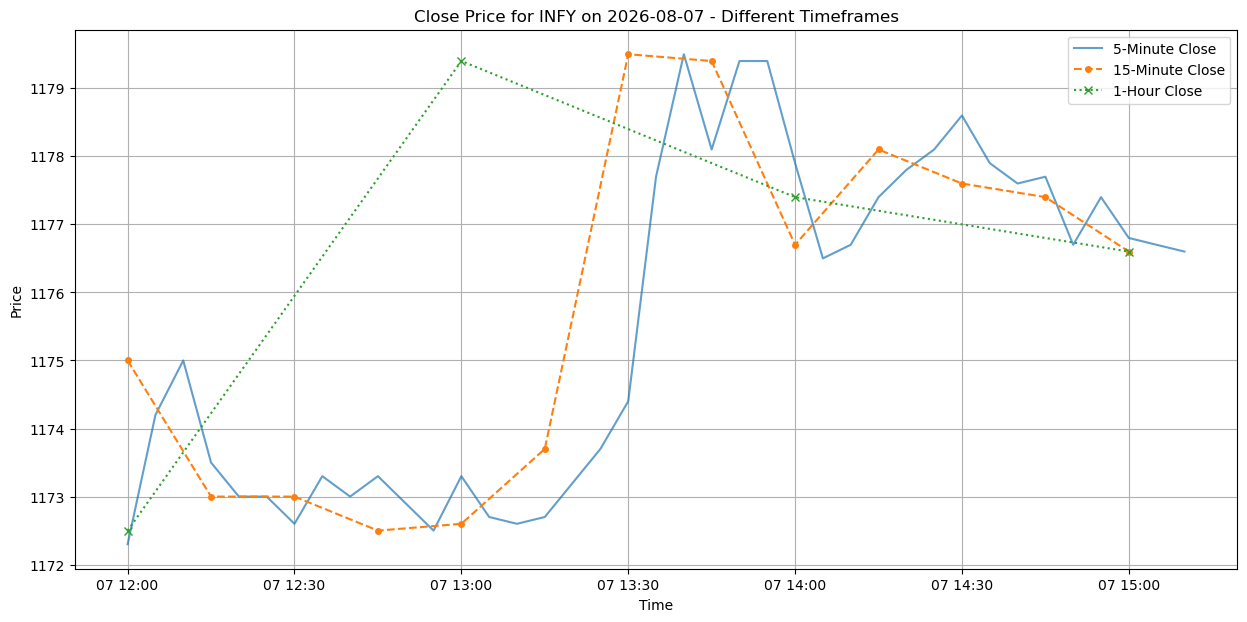

In [7]:
if 'df_5m' in locals():
    # Get data for the last trading day
    last_day = df_5m.index.date[1].strftime('%Y-%m-%d')

    plt.figure(figsize=(15, 7))

    # Plot 5-minute data
    plt.plot(df_5m.loc[last_day].index, df_5m.loc[last_day]['close'], label='5-Minute Close', alpha=0.7)

    # Plot 15-minute data
    plt.plot(df_15m.loc[last_day].index, df_15m.loc[last_day]['close'], label='15-Minute Close', linestyle='--', marker='o', markersize=4)

    # Plot 1-hour data
    plt.plot(df_1h.loc[last_day].index, df_1h.loc[last_day]['close'], label='1-Hour Close', linestyle=':', marker='x', markersize=6)

    plt.title(f'Close Price for {symbol} on {last_day} - Different Timeframes')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()


## Conclusion

You are now equipped to handle one of the most fundamental tasks in quantitative finance: fetching and manipulating historical data. You can download OHLCV data for any instrument on any timeframe supported by the API.

More importantly, you can use the power of Pandas to resample this data to any lower frequency you need. This skill is indispensable for building multi-timeframe analysis models and backtesting strategies across different periodicities.<br><br>